# **How to Build and Fine-Tune a Small Language Model**

*--A Step-by-Step Guide for Beginners, Researchers, and Non-Programmers*

1) Paper Version: https://www.amazon.com/dp/B0G3MYWTJK

2) PDF version: https://leanpub.com/howtobuildandfine-tuneasmalllanguagemodel

Reference:

Liu, J. Paul. 2025. How to Build and Fine-Tune a Small Language Model. Leanpub. 479 p.

# Chapter 6: Training Loop & Monitoring.ipynb

## Part 1: The Training Loop Fundamentals

Remember from Chapter 2 when you wrote this simple training loop?

In [ ]:
'''
#python
for steps in range(10000):
    xb, yb = get_batch('train')
    logits, loss = model(xb, yb)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
'''

"\n#python\nfor steps in range(10000):\n    xb, yb = get_batch('train')\n    logits, loss = model(xb, yb)\n    optimizer.zero_grad()\n    loss.backward()\n    optimizer.step()\n"

### Anatomy of a Production Training Loop

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import time
import os
import json

class TrainingConfig:
    """All training hyperparameters in one place"""

    def __init__(self):
        # Training
        self.max_iters = 100000
        self.batch_size = 12
        self.gradient_accumulation_steps = 4  # Effective batch = 12 × 4 = 48

        # Optimization
        self.learning_rate = 3e-4
        self.weight_decay = 0.1
        self.beta1 = 0.9
        self.beta2 = 0.95
        self.grad_clip = 1.0

        # Learning rate schedule
        self.warmup_iters = 2000
        self.lr_decay_iters = 100000
        self.min_lr = 3e-5  # 10% of max

        # Evaluation
        self.eval_interval = 500
        self.eval_iters = 200

        # Checkpointing
        self.save_interval = 1000
        self.checkpoint_dir = './checkpoints'

        # Logging
        self.log_interval = 10

class Trainer:
    """Production training pipeline"""

    def __init__(self, model, train_data, val_data, config):
        self.model = model
        self.train_data = train_data
        self.val_data = val_data
        self.config = config

        # Setup optimizer
        self.optimizer = self.configure_optimizer()

        # Setup data loaders
        self.train_loader = DataLoader(
            train_data,
            batch_size=config.batch_size,
            shuffle=True,
            pin_memory=True,
        )

        # Training state
        self.iter_num = 0
        self.best_val_loss = float('inf')

        # Create checkpoint directory
        os.makedirs(config.checkpoint_dir, exist_ok=True)

    def configure_optimizer(self):
        """
        Configure AdamW optimizer with weight decay.
        Based on GPT-3 paper recommendations.
        """
        # Separate parameters that should and shouldn't have weight decay
        decay_params = []
        no_decay_params = []

        for name, param in self.model.named_parameters():
            if param.requires_grad:
                # No decay for bias and LayerNorm
                if 'bias' in name or 'ln' in name or 'layernorm' in name:
                    no_decay_params.append(param)
                else:
                    decay_params.append(param)

        optim_groups = [
            {'params': decay_params, 'weight_decay': self.config.weight_decay},
            {'params': no_decay_params, 'weight_decay': 0.0}
        ]

        optimizer = torch.optim.AdamW(
            optim_groups,
            lr=self.config.learning_rate,
            betas=(self.config.beta1, self.config.beta2)
        )

        return optimizer

    def get_lr(self, iter_num):
        """
        Learning rate schedule with warmup and cosine decay.
        Based on GPT-3 paper.
        """
        # Linear warmup
        if iter_num < self.config.warmup_iters:
            return self.config.learning_rate * iter_num / self.config.warmup_iters

        # Cosine decay after warmup
        if iter_num > self.config.lr_decay_iters:
            return self.config.min_lr

        decay_ratio = (iter_num - self.config.warmup_iters) / (self.config.lr_decay_iters - self.config.warmup_iters)
        coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio))
        return self.config.min_lr + coeff * (self.config.learning_rate - self.config.min_lr)

    def train_step(self, batch):
        """Single training step"""
        self.model.train()

        x, y = batch
        x, y = x.to(self.device), y.to(self.device)

        # Forward pass
        logits, loss = self.model(x, y)

        # Scale loss by gradient accumulation
        loss = loss / self.config.gradient_accumulation_steps

        # Backward pass
        loss.backward()

        return loss.item() * self.config.gradient_accumulation_steps

    @torch.no_grad()
    def evaluate(self):
        """Evaluate on validation set"""
        self.model.eval()
        losses = []

        for i in range(self.config.eval_iters):
            x, y = self.get_batch('val')
            x, y = x.to(self.device), y.to(self.device)
            logits, loss = self.model(x, y)
            losses.append(loss.item())

        return sum(losses) / len(losses)

    def save_checkpoint(self, is_best=False):
        """Save training checkpoint"""
        checkpoint = {
            'iter_num': self.iter_num,
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'config': self.config.__dict__,
            'best_val_loss': self.best_val_loss,
        }

        # Save regular checkpoint
        path = os.path.join(self.config.checkpoint_dir, f'ckpt_iter_{self.iter_num}.pt')
        torch.save(checkpoint, path)
        print(f"Saved checkpoint to {path}")

        # Save best model
        if is_best:
            best_path = os.path.join(self.config.checkpoint_dir, 'best_model.pt')
            torch.save(checkpoint, best_path)
            print(f"New best model saved! Val loss: {self.best_val_loss:.4f}")

    def train(self):
        """Main training loop"""
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model.to(self.device)

        print("Starting training...")
        print(f"Device: {self.device}")
        print(f"Model parameters: {sum(p.numel() for p in self.model.parameters())/1e6:.2f}M")
        print(f"Max iterations: {self.config.max_iters}")

        running_loss = 0.0
        start_time = time.time()

        while self.iter_num < self.config.max_iters:
            # Update learning rate
            lr = self.get_lr(self.iter_num)
            for param_group in self.optimizer.param_groups:
                param_group['lr'] = lr

            # Training steps with gradient accumulation
            for micro_step in range(self.config.gradient_accumulation_steps):
                batch = next(iter(self.train_loader))
                loss = self.train_step(batch)
                running_loss += loss

            # Gradient clipping (prevents exploding gradients)
            if self.config.grad_clip > 0:
                torch.nn.utils.clip_grad_norm_(
                    self.model.parameters(),
                    self.config.grad_clip
                )

            # Optimizer step
            self.optimizer.step()
            self.optimizer.zero_grad(set_to_none=True)

            self.iter_num += 1

            # Logging
            if self.iter_num % self.config.log_interval == 0:
                elapsed = time.time() - start_time
                avg_loss = running_loss / self.config.log_interval
                print(
                    f"iter {self.iter_num:6d} | "
                    f"loss {avg_loss:.4f} | "
                    f"lr {lr:.2e} | "
                    f"time {elapsed:.2f}s"
                )
                running_loss = 0.0
                start_time = time.time()

            # Evaluation
            if self.iter_num % self.config.eval_interval == 0:
                val_loss = self.evaluate()
                print(f"\nValidation loss: {val_loss:.4f}")

                # Save if best
                is_best = val_loss < self.best_val_loss
                if is_best:
                    self.best_val_loss = val_loss

                self.save_checkpoint(is_best=is_best)

            # Regular checkpointing
            elif self.iter_num % self.config.save_interval == 0:
                self.save_checkpoint()

        print("\nTraining complete!")

# Example usage
config = TrainingConfig()
#trainer = Trainer(model, train_data, val_data, config)
#trainer.train()

This is a complete, production-ready training loop. Let's break down each component.

## Part 2: Understanding Key Components

### 1. Gradient Accumulation

**Problem:** Your batch size is limited by GPU memory. You want batch_size=48, but only fit 12.

**Solution:** Accumulate gradients over multiple small batches.

In [ ]:
# Without gradient accumulation (batch_size=12)
'''
for batch in dataloader:
    loss = model(batch)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

# With gradient accumulation (effective batch_size=48)
gradient_accumulation_steps = 4

for batch in dataloader:
    loss = model(batch)
    loss = loss / gradient_accumulation_steps  # Scale the loss
    loss.backward()  # Gradients accumulate

    if (step + 1) % gradient_accumulation_steps == 0:
        optimizer.step()
        optimizer.zero_grad()
  '''

'\nfor batch in dataloader:\n    loss = model(batch)\n    loss.backward()\n    optimizer.step()\n    optimizer.zero_grad()\n\n# With gradient accumulation (effective batch_size=48)\ngradient_accumulation_steps = 4\n\nfor batch in dataloader:\n    loss = model(batch)\n    loss = loss / gradient_accumulation_steps  # Scale the loss\n    loss.backward()  # Gradients accumulate\n    \n    if (step + 1) % gradient_accumulation_steps == 0:\n        optimizer.step()\n        optimizer.zero_grad()\n  '

### 2. Learning Rate Scheduling

**Why needed:** A fixed learning rate is suboptimal.
- **Too high at start:** Model diverges (loss goes to infinity)
- **Too high at end:** Model bounces around, can't converge
- **Too low throughout:** Training takes forever

**Solution:** Warmup + Cosine Decay

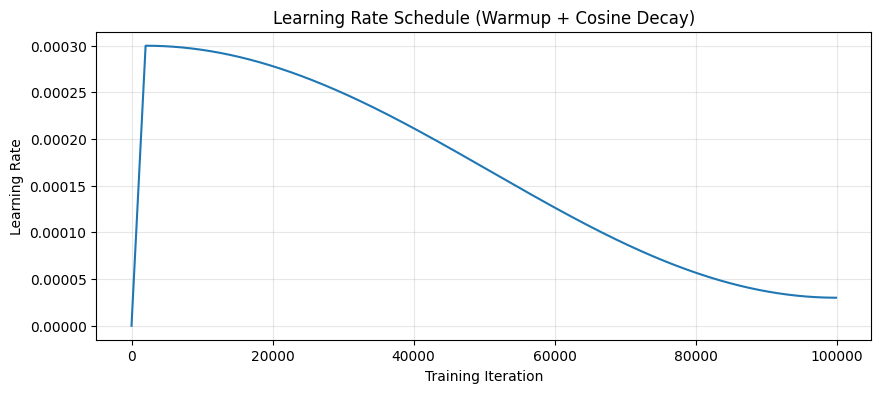

In [ ]:
import math

def get_learning_rate(iter_num, max_lr=3e-4, min_lr=3e-5, warmup_iters=2000, max_iters=100000):
    """
    Learning rate schedule:
    1. Linear warmup from 0 to max_lr (first 2000 steps)
    2. Cosine decay from max_lr to min_lr (rest of training)
    """
    # 1. Warmup
    if iter_num < warmup_iters:
        return max_lr * iter_num / warmup_iters

    # 2. Cosine decay
    if iter_num > max_iters:
        return min_lr

    decay_ratio = (iter_num - warmup_iters) / (max_iters - warmup_iters)
    coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio))  # 1.0 to 0.0
    return min_lr + coeff * (max_lr - min_lr)

# Visualize the schedule
import matplotlib.pyplot as plt
import numpy as np

iters = np.arange(0, 100000, 100)
lrs = [get_learning_rate(i) for i in iters]

plt.figure(figsize=(10, 4))
plt.plot(iters, lrs)
plt.xlabel('Training Iteration')
plt.ylabel('Learning Rate')
plt.title('Learning Rate Schedule (Warmup + Cosine Decay)')
plt.grid(True, alpha=0.3)
plt.show()

### 3. Gradient Clipping

**Problem:** Sometimes gradients become extremely large ("exploding gradients"), causing training to diverge.

**Solution:** Clip gradients to maximum norm.

In [ ]:
'''
# After computing gradients
max_grad_norm = 1.0
torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)

# Then do optimizer step
optimizer.step()
'''

'\n# After computing gradients\nmax_grad_norm = 1.0\ntorch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)\n\n# Then do optimizer step\noptimizer.step()\n'

### 4. Weight Decay (L2 Regularization)

**Why needed:** Prevents overfitting by penalizing large weights.

**How to apply:** Different for different parameter types.

In [ ]:
# Good practice: No weight decay on bias and LayerNorm parameters
decay_params = []
no_decay_params = []

for name, param in model.named_parameters():
    if 'bias' in name or 'ln' in name:
        no_decay_params.append(param)
    else:
        decay_params.append(param)

optimizer = torch.optim.AdamW([
    {'params': decay_params, 'weight_decay': 0.1},
    {'params': no_decay_params, 'weight_decay': 0.0}
], lr=3e-4)

NameError: name 'model' is not defined

## Part 3: Monitoring and Logging

### Basic Logging to Console


In [ ]:
def train_with_logging(model, train_data, val_data, config):
    """Training loop with console logging"""

    for iter_num in range(config.max_iters):
        # Training step
        loss = train_step(...)

        # Log every 10 iterations
        if iter_num % 10 == 0:
            print(f"iter {iter_num:6d} | loss {loss:.4f} | lr {lr:.2e}")

        # Evaluate every 500 iterations
        if iter_num % 500 == 0:
            val_loss = evaluate(...)
            print(f"\n{'='*50}")
            print(f"Iteration {iter_num}")
            print(f"Train loss: {loss:.4f}")
            print(f"Val loss: {val_loss:.4f}")
            print(f"{'='*50}\n")

### TensorBoard: Visual Monitoring

In [ ]:
from torch.utils.tensorboard import SummaryWriter

class TensorBoardTrainer:
    """Training with TensorBoard logging"""

    def __init__(self, model, config):
        self.model = model
        self.config = config
        self.writer = SummaryWriter(log_dir='./runs/experiment_1')

    def train(self):
        for iter_num in range(self.config.max_iters):
            # Training step
            loss = self.train_step(...)

            # Log to TensorBoard
            self.writer.add_scalar('Loss/train', loss, iter_num)
            self.writer.add_scalar('Learning_rate', lr, iter_num)

            if iter_num % 500 == 0:
                val_loss = self.evaluate()
                self.writer.add_scalar('Loss/validation', val_loss, iter_num)

                # Log model gradients
                for name, param in self.model.named_parameters():
                    if param.grad is not None:
                        self.writer.add_histogram(f'Gradients/{name}', param.grad, iter_num)

        self.writer.close()

# View in TensorBoard
# Run in terminal: tensorboard --logdir=./runs
# Open browser: http://localhost:6006

### Weights & Biases (WandB): Cloud Monitoring

In [ ]:
!pip install wandb -q

import wandb

class WandBTrainer:
    """Training with Weights & Biases"""

    def __init__(self, model, config):
        self.model = model
        self.config = config

        # Initialize wandb
        wandb.init(
            project="small-llm-training",
            config=config.__dict__,
            name="gpt-125m-run1"
        )

        # Watch model
        wandb.watch(model, log='all', log_freq=100)

    def train(self):
        for iter_num in range(self.config.max_iters):
            loss = self.train_step(...)

            # Log to wandb
            wandb.log({
                'train/loss': loss,
                'train/learning_rate': lr,
                'train/iteration': iter_num,
            })

            if iter_num % 500 == 0:
                val_loss = self.evaluate()

                wandb.log({
                    'val/loss': val_loss,
                    'val/iteration': iter_num,
                })

                # Log sample generations
                sample_text = self.generate_sample()
                wandb.log({'samples/text': wandb.Html(sample_text)})

        wandb.finish()

# Access dashboard at: https://wandb.ai/your-username/small-llm-training

## Part 4: Checkpointing and Recovery

**Why checkpoint:** Training can fail (power outage, OOM error, kernel crash). Checkpoints let you resume.

### Basic Checkpointing

In [ ]:
def save_checkpoint(model, optimizer, iter_num, loss, filepath):
    """Save training state"""
    checkpoint = {
        'iter_num': iter_num,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
    }
    torch.save(checkpoint, filepath)
    print(f"Checkpoint saved to {filepath}")

def load_checkpoint(model, optimizer, filepath):
    """Load training state"""
    checkpoint = torch.load(filepath)

    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    iter_num = checkpoint['iter_num']
    loss = checkpoint['loss']

    print(f"Checkpoint loaded from {filepath}")
    print(f"Resuming from iteration {iter_num}, loss {loss:.4f}")

    return iter_num, loss

# Save every 1000 iterations
if iter_num % 1000 == 0:
    save_checkpoint(
        model, optimizer, iter_num, loss,
        f'./checkpoints/ckpt_iter_{iter_num}.pt'
    )

# Resume training
iter_num, loss = load_checkpoint(model, optimizer, './checkpoints/ckpt_iter_5000.pt')
# Continue training from iteration 5000

NameError: name 'iter_num' is not defined

### Smart Checkpointing Strategy


In [ ]:
class CheckpointManager:
    """Manage checkpoints efficiently"""

    def __init__(self, checkpoint_dir, keep_last_n=3):
        self.checkpoint_dir = checkpoint_dir
        self.keep_last_n = keep_last_n
        self.checkpoints = []
        self.best_checkpoint = None
        self.best_val_loss = float('inf')

        os.makedirs(checkpoint_dir, exist_ok=True)

    def save(self, model, optimizer, iter_num, val_loss, is_scheduled=True):
        """
        Save checkpoint.

        is_scheduled: True for regular checkpoints, False for best model
        """
        checkpoint = {
            'iter_num': iter_num,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
        }

        if is_scheduled:
            # Save regular checkpoint
            filepath = os.path.join(self.checkpoint_dir, f'ckpt_{iter_num}.pt')
            torch.save(checkpoint, filepath)
            self.checkpoints.append((iter_num, filepath))

            # Keep only last N checkpoints
            if len(self.checkpoints) > self.keep_last_n:
                old_iter, old_path = self.checkpoints.pop(0)
                if os.path.exists(old_path):
                    os.remove(old_path)
                    print(f"Removed old checkpoint: {old_path}")

        # Save best model
        if val_loss < self.best_val_loss:
            self.best_val_loss = val_loss
            best_path = os.path.join(self.checkpoint_dir, 'best_model.pt')
            torch.save(checkpoint, best_path)
            print(f"New best model! Val loss: {val_loss:.4f}")

    def load_best(self, model, optimizer):
        """Load best model"""
        best_path = os.path.join(self.checkpoint_dir, 'best_model.pt')
        if not os.path.exists(best_path):
            print("No best model found")
            return None

        checkpoint = torch.load(best_path)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

        print(f"Loaded best model with val loss: {checkpoint['val_loss']:.4f}")
        return checkpoint['iter_num']

# Usage
ckpt_manager = CheckpointManager('./checkpoints', keep_last_n=3)

# During training
if iter_num % 1000 == 0:
    val_loss = evaluate()
    ckpt_manager.save(model, optimizer, iter_num, val_loss, is_scheduled=True)

# Load best model for inference
ckpt_manager.load_best(model, optimizer)

NameError: name 'iter_num' is not defined


## Part 6: Complete Training Script

Here's a complete, production-ready training script:


NOTE: To train this model, you need to change runtime type to **A100 GPU**, T4 has not eough memory.

---



First let's get train and val dataset

In [ ]:
"""
prepare_training_data.py - Create train.pt and val.pt for language model training
Handles multiple data sources with robust error handling
"""

import torch
from transformers import AutoTokenizer
import numpy as np
from datasets import load_dataset
import os

class DatasetPreparer:
    def __init__(self, tokenizer_name="gpt2", max_length=1024):
        """Initialize with tokenizer"""
        print(f"Loading tokenizer: {tokenizer_name}")
        self.tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
        self.max_length = max_length

        # Set padding token if not exists
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

    def tokenize_texts(self, texts, desc="Tokenizing"):
        """Tokenize list of texts into token IDs"""
        all_tokens = []

        print(f"\n{desc}...")
        for i, text in enumerate(texts):
            if i % 1000 == 0 and i > 0:
                print(f"  Processed {i}/{len(texts)} texts...")

            # Tokenize
            tokens = self.tokenizer.encode(
                text,
                max_length=self.max_length,
                truncation=True,
                add_special_tokens=True
            )
            all_tokens.extend(tokens)

        print(f"  Total tokens: {len(all_tokens):,}")
        return all_tokens

    def create_sequences(self, tokens, seq_length=1024):
        """Create fixed-length sequences from tokens"""
        sequences = []

        # Create overlapping sequences
        for i in range(0, len(tokens) - seq_length, seq_length):
            seq = tokens[i:i + seq_length]
            if len(seq) == seq_length:
                sequences.append(seq)

        print(f"  Created {len(sequences):,} sequences of length {seq_length}")
        return sequences

    def prepare_and_save(self, texts, output_path, seq_length=1024, val_split=0.1):
        """Complete pipeline: tokenize, split, save"""

        # Tokenize
        all_tokens = self.tokenize_texts(texts)

        # Create sequences
        print(f"\nCreating sequences...")
        sequences = self.create_sequences(all_tokens, seq_length)

        # Split train/val
        n_val = int(len(sequences) * val_split)
        n_train = len(sequences) - n_val

        print(f"\nSplitting data:")
        print(f"  Training sequences: {n_train:,}")
        print(f"  Validation sequences: {n_val:,}")

        # Shuffle
        np.random.seed(42)
        indices = np.random.permutation(len(sequences))

        train_sequences = [sequences[i] for i in indices[:n_train]]
        val_sequences = [sequences[i] for i in indices[n_train:]]

        # Convert to tensors
        train_tensor = torch.tensor(train_sequences, dtype=torch.long)
        val_tensor = torch.tensor(val_sequences, dtype=torch.long)

        # Save
        train_path = os.path.join(output_path, 'train.pt')
        val_path = os.path.join(output_path, 'val.pt')

        print(f"\nSaving datasets...")
        torch.save(train_tensor, train_path)
        torch.save(val_tensor, val_path)

        print(f"✅ Saved:")
        print(f"  {train_path}: {train_tensor.shape}")
        print(f"  {val_path}: {val_tensor.shape}")

        return train_tensor, val_tensor


# ============================================================================
# DATA SOURCE OPTIONS - Choose one that works for you
# ============================================================================

def option1_wikipedia(num_samples=10000):
    """Option 1: Wikipedia (Reliable)"""
    print("\n=== Loading Wikipedia Dataset ===")
    try:
        dataset = load_dataset(
            "wikimedia/wikipedia",
            "20231101.en",
            split="train",
            streaming=True
        )

        texts = []
        for i, item in enumerate(dataset):
            if i >= num_samples:
                break
            texts.append(item['text'])
            if i % 1000 == 0:
                print(f"Loaded {i} articles...")

        print(f"✅ Loaded {len(texts)} Wikipedia articles")
        return texts
    except Exception as e:
        print(f"❌ Wikipedia error: {e}")
        return None


def option2_books(num_samples=5000):
    """Option 2: Books (BookCorpus style)"""
    print("\n=== Loading Books Dataset ===")
    try:
        dataset = load_dataset("bookcorpus", split=f"train[:{num_samples}]")
        texts = [item['text'] for item in dataset]
        print(f"✅ Loaded {len(texts)} book excerpts")
        return texts
    except Exception as e:
        print(f"❌ Books error: {e}")
        return None


def option3_c4(num_samples=10000):
    """Option 3: C4 Web Text (High Quality)"""
    print("\n=== Loading C4 Dataset ===")
    try:
        dataset = load_dataset(
            "allenai/c4",
            "en",
            split="train",
            streaming=True
        )

        texts = []
        for i, item in enumerate(dataset):
            if i >= num_samples:
                break
            texts.append(item['text'])
            if i % 1000 == 0:
                print(f"Loaded {i} documents...")

        print(f"✅ Loaded {len(texts)} C4 documents")
        return texts
    except Exception as e:
        print(f"❌ C4 error: {e}")
        return None


def option4_openwebtext(num_samples=10000):
    """Option 4: OpenWebText (Reddit links)"""
    print("\n=== Loading OpenWebText ===")
    try:
        dataset = load_dataset("openwebtext", split=f"train[:{num_samples}]")
        texts = [item['text'] for item in dataset]
        print(f"✅ Loaded {len(texts)} web texts")
        return texts
    except Exception as e:
        print(f"❌ OpenWebText error: {e}")
        return None


def option5_mixed_sources(samples_per_source=2000):
    """Option 5: Mix multiple sources"""
    print("\n=== Loading Mixed Dataset ===")
    all_texts = []

    # Try multiple sources
    sources = [
        ("Wikipedia", option1_wikipedia),
        ("C4", option3_c4),
        ("OpenWebText", option4_openwebtext),
    ]

    for name, loader_func in sources:
        try:
            print(f"\nTrying {name}...")
            texts = loader_func(samples_per_source)
            if texts:
                all_texts.extend(texts)
                print(f"  Added {len(texts)} texts from {name}")
        except Exception as e:
            print(f"  Skipped {name}: {e}")

    if all_texts:
        print(f"\n✅ Total texts from all sources: {len(all_texts)}")
        return all_texts
    else:
        print("❌ No sources worked")
        return None


def option6_tiny_shakespeare():
    """Option 6: Tiny Shakespeare (for quick testing)"""
    print("\n=== Loading Tiny Shakespeare ===")
    try:
        dataset = load_dataset("tiny_shakespeare", split="train")
        text = dataset[0]['text']

        # Split into chunks
        chunk_size = 1000
        texts = [text[i:i+chunk_size] for i in range(0, len(text), chunk_size)]

        print(f"✅ Loaded Shakespeare: {len(texts)} chunks")
        return texts
    except Exception as e:
        print(f"❌ Shakespeare error: {e}")
        return None


# ============================================================================
# MAIN EXECUTION
# ============================================================================

def main():
    """Main data preparation pipeline"""

    # Configuration
    OUTPUT_DIR = "./"
    SEQ_LENGTH = 1024
    NUM_SAMPLES = 10000

    os.makedirs(OUTPUT_DIR, exist_ok=True)

    print("="*70)
    print("LANGUAGE MODEL DATA PREPARATION")
    print("="*70)

    # Try different data sources in order of preference
    print("\nTrying data sources...")

    texts = None

    # Try sources in order
    sources_to_try = [
        ("Wikipedia", lambda: option1_wikipedia(NUM_SAMPLES)),
        ("C4", lambda: option3_c4(NUM_SAMPLES)),
        ("OpenWebText", lambda: option4_openwebtext(NUM_SAMPLES)),
        ("Mixed Sources", lambda: option5_mixed_sources(NUM_SAMPLES // 3)),
        ("Tiny Shakespeare", option6_tiny_shakespeare),
    ]

    for name, loader in sources_to_try:
        print(f"\n{'='*70}")
        print(f"Attempting: {name}")
        print('='*70)

        try:
            texts = loader()
            if texts and len(texts) > 0:
                print(f"✅ Successfully loaded {len(texts)} texts from {name}")
                break
        except Exception as e:
            print(f"❌ {name} failed: {e}")
            texts = None

    # If nothing worked, create dummy data
    if not texts:
        print("\n⚠️  All sources failed. Creating dummy data for testing...")
        texts = [
            "The quick brown fox jumps over the lazy dog. " * 100
            for _ in range(1000)
        ]

    # Prepare data
    print(f"\n{'='*70}")
    print("TOKENIZING AND PREPARING DATA")
    print('='*70)

    preparer = DatasetPreparer(tokenizer_name="gpt2", max_length=SEQ_LENGTH)
    train_tensor, val_tensor = preparer.prepare_and_save(
        texts,
        OUTPUT_DIR,
        seq_length=SEQ_LENGTH,
        val_split=0.1
    )

    # Summary
    print(f"\n{'='*70}")
    print("SUMMARY")
    print('='*70)
    print(f"✅ Data preparation complete!")
    print(f"")
    print(f"Training data:   {train_tensor.shape[0]:,} sequences")
    print(f"Validation data: {val_tensor.shape[0]:,} sequences")
    print(f"Sequence length: {train_tensor.shape[1]}")
    print(f"")
    print(f"Files created:")
    print(f"  - train.pt")
    print(f"  - val.pt")
    print(f"")
    print(f"You can now run: python train.py")
    print('='*70)


if __name__ == "__main__":
    main()

LANGUAGE MODEL DATA PREPARATION

Trying data sources...

Attempting: Wikipedia

=== Loading Wikipedia Dataset ===


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/41 [00:00<?, ?it/s]

Loaded 0 articles...
Loaded 1000 articles...
Loaded 2000 articles...
Loaded 3000 articles...
Loaded 4000 articles...
Loaded 5000 articles...
Loaded 6000 articles...
Loaded 7000 articles...
Loaded 8000 articles...
Loaded 9000 articles...
✅ Loaded 10000 Wikipedia articles
✅ Successfully loaded 10000 texts from Wikipedia

TOKENIZING AND PREPARING DATA
Loading tokenizer: gpt2


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]


Tokenizing...
  Processed 1000/10000 texts...
  Processed 2000/10000 texts...
  Processed 3000/10000 texts...
  Processed 4000/10000 texts...
  Processed 5000/10000 texts...
  Processed 6000/10000 texts...
  Processed 7000/10000 texts...
  Processed 8000/10000 texts...
  Processed 9000/10000 texts...
  Total tokens: 6,884,043

Creating sequences...
  Created 6,722 sequences of length 1024

Splitting data:
  Training sequences: 6,050
  Validation sequences: 672

Saving datasets...
✅ Saved:
  ./train.pt: torch.Size([6050, 1024])
  ./val.pt: torch.Size([672, 1024])

SUMMARY
✅ Data preparation complete!

Training data:   6,050 sequences
Validation data: 672 sequences
Sequence length: 1024

Files created:
  - train.pt
  - val.pt

You can now run: python train.py


Then

In [ ]:
"""
train.py - Complete training script for language models with integrated model
"""

import torch
import torch.nn as nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, TensorDataset
import os
import time
import math
from dataclasses import dataclass

# ============================================================================
# MODEL ARCHITECTURE (from Chapter 5)
# ============================================================================

class ConfigurableGPT(nn.Module):
    """
    GPT model with flexible configuration.
    Based on Chapter 2's architecture but fully configurable.
    """

    def __init__(self, config):
        super().__init__()
        self.config = config

        # Validate configuration
        assert config['n_embd'] % config['n_head'] == 0, \
            f"n_embd ({config['n_embd']}) must be divisible by n_head ({config['n_head']})"

        # Token + position embeddings
        self.token_embedding = nn.Embedding(config['vocab_size'], config['n_embd'])
        self.position_embedding = nn.Embedding(config['block_size'], config['n_embd'])

        # Transformer blocks
        self.blocks = nn.ModuleList([
            TransformerBlock(config) for _ in range(config['n_layer'])
        ])

        # Output
        self.ln_f = nn.LayerNorm(config['n_embd'])
        self.lm_head = nn.Linear(config['n_embd'], config['vocab_size'], bias=False)

        # Dropout
        self.dropout = nn.Dropout(config['dropout'])

        # Initialize weights
        self.apply(self._init_weights)

        print(f"Model initialized with {self.count_parameters()/1e6:.1f}M parameters")

    def _init_weights(self, module):
        """Initialize weights (important for training stability)"""
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def count_parameters(self):
        """Count total parameters"""
        return sum(p.numel() for p in self.parameters())

    def forward(self, idx, targets=None):
        """
        Forward pass.

        idx: (batch, time) tensor of token indices
        targets: (batch, time) tensor of target indices (optional)
        """
        B, T = idx.shape

        # Embeddings
        tok_emb = self.token_embedding(idx)  # (B, T, n_embd)
        pos_emb = self.position_embedding(torch.arange(T, device=idx.device))  # (T, n_embd)
        x = self.dropout(tok_emb + pos_emb)  # (B, T, n_embd)

        # Transformer blocks
        for block in self.blocks:
            x = block(x)

        # Output
        x = self.ln_f(x)
        logits = self.lm_head(x)  # (B, T, vocab_size)

        # Calculate loss if targets provided
        loss = None
        if targets is not None:
            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)),
                targets.view(-1),
                ignore_index=-1
            )

        return logits, loss


class TransformerBlock(nn.Module):
    """Single transformer block"""

    def __init__(self, config):
        super().__init__()

        self.ln1 = nn.LayerNorm(config['n_embd'])
        self.attn = MultiHeadAttention(config)
        self.ln2 = nn.LayerNorm(config['n_embd'])
        self.mlp = FeedForward(config)

    def forward(self, x):
        # Pre-normalization (more stable than post-norm)
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x


class MultiHeadAttention(nn.Module):
    """Multi-head self-attention"""

    def __init__(self, config):
        super().__init__()
        assert config['n_embd'] % config['n_head'] == 0

        self.n_head = config['n_head']
        self.n_embd = config['n_embd']
        self.head_size = config['n_embd'] // config['n_head']

        # QKV projection
        self.c_attn = nn.Linear(config['n_embd'], 3 * config['n_embd'])
        # Output projection
        self.c_proj = nn.Linear(config['n_embd'], config['n_embd'])

        # Dropout
        self.attn_dropout = nn.Dropout(config['dropout'])
        self.resid_dropout = nn.Dropout(config['dropout'])

        # Causal mask
        self.register_buffer(
            "mask",
            torch.tril(torch.ones(config['block_size'], config['block_size']))
                .view(1, 1, config['block_size'], config['block_size'])
        )

    def forward(self, x):
        B, T, C = x.shape

        # Calculate Q, K, V
        qkv = self.c_attn(x)
        q, k, v = qkv.split(self.n_embd, dim=2)

        # Reshape for multi-head
        k = k.view(B, T, self.n_head, self.head_size).transpose(1, 2)
        q = q.view(B, T, self.n_head, self.head_size).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.head_size).transpose(1, 2)

        # Attention scores
        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        att = att.masked_fill(self.mask[:,:,:T,:T] == 0, float('-inf'))
        att = F.softmax(att, dim=-1)
        att = self.attn_dropout(att)

        # Apply attention to values
        y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)

        # Output projection
        y = self.resid_dropout(self.c_proj(y))
        return y


class FeedForward(nn.Module):
    """Position-wise feed-forward network"""

    def __init__(self, config):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config['n_embd'], 4 * config['n_embd']),
            nn.GELU(),
            nn.Linear(4 * config['n_embd'], config['n_embd']),
            nn.Dropout(config['dropout']),
        )

    def forward(self, x):
        return self.net(x)


# ============================================================================
# MODEL CONFIGURATIONS (from Chapter 5)
# ============================================================================

# Fast prototype configuration (50M parameters)
config_fast = {
    'vocab_size': 50257,      # GPT-2 tokenizer size
    'n_embd': 512,
    'n_layer': 8,
    'n_head': 8,
    'block_size': 256,
    'dropout': 0.1,
}

# Medium configuration (350M parameters)
config_medium = {
    'vocab_size': 50257,
    'n_embd': 1024,
    'n_layer': 24,
    'n_head': 16,
    'block_size': 512,
    'dropout': 0.1,
}

# Large configuration (1B parameters)
config_large = {
    'vocab_size': 50257,
    'n_embd': 1280,
    'n_layer': 36,
    'n_head': 20,
    'block_size': 1024,
    'dropout': 0.1,
}


# ============================================================================
# TRAINING CONFIGURATION
# ============================================================================

@dataclass
class TrainConfig:
    # Model
    model_config: dict

    # Data
    train_data_path: str
    val_data_path: str

    # Training
    max_iters: int = 100000
    batch_size: int = 12
    gradient_accumulation_steps: int = 4

    # Optimization
    learning_rate: float = 3e-4
    weight_decay: float = 0.1
    beta1: float = 0.9
    beta2: float = 0.95
    grad_clip: float = 1.0

    # Schedule
    warmup_iters: int = 2000
    lr_decay_iters: int = 100000
    min_lr: float = 3e-5

    # Evaluation & Logging
    eval_interval: int = 500
    eval_iters: int = 200
    log_interval: int = 10

    # Checkpointing
    checkpoint_dir: str = './checkpoints'
    save_interval: int = 1000

    # Misc
    device: str = 'cuda' if torch.cuda.is_available() else 'cpu'


# ============================================================================
# TRAINING FUNCTIONS
# ============================================================================

def get_lr(iter_num, config):
    """Learning rate schedule with warmup and cosine decay"""
    if iter_num < config.warmup_iters:
        return config.learning_rate * iter_num / config.warmup_iters
    if iter_num > config.lr_decay_iters:
        return config.min_lr
    decay_ratio = (iter_num - config.warmup_iters) / (config.lr_decay_iters - config.warmup_iters)
    coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio))
    return config.min_lr + coeff * (config.learning_rate - config.min_lr)


def train(model, train_data, val_data, config):
    """Main training function"""

    # Setup
    device = torch.device(config.device)
    model.to(device)

    # Data loaders
    train_loader = DataLoader(
        TensorDataset(train_data),
        batch_size=config.batch_size,
        shuffle=True,
        pin_memory=True
    )

    # Optimizer
    optimizer = configure_optimizer(model, config)

    # Checkpoint manager
    os.makedirs(config.checkpoint_dir, exist_ok=True)
    best_val_loss = float('inf')

    # Training loop
    print(f"Starting training on {device}")
    print(f"Model: {sum(p.numel() for p in model.parameters())/1e6:.2f}M parameters")

    model.train()
    running_loss = 0.0
    iter_num = 0

    while iter_num < config.max_iters:
        t0 = time.time()

        # Get batch
        try:
            batch = next(train_iter)
        except:
            train_iter = iter(train_loader)
            batch = next(train_iter)

        # Forward & backward with gradient accumulation
        loss_accum = 0.0
        for micro_step in range(config.gradient_accumulation_steps):
            x = batch[0].to(device)
            # Create targets (shifted by 1)
            y = torch.cat([x[:, 1:], x[:, :1]], dim=1)

            logits, loss = model(x, y)
            loss = loss / config.gradient_accumulation_steps
            loss_accum += loss.item()
            loss.backward()

        # Clip gradients
        if config.grad_clip > 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), config.grad_clip)

        # Update weights
        lr = get_lr(iter_num, config)
        for param_group in optimizer.param_groups:
            param_group['lr'] = lr

        optimizer.step()
        optimizer.zero_grad(set_to_none=True)

        # Logging
        running_loss += loss_accum
        t1 = time.time()

        if iter_num % config.log_interval == 0:
            avg_loss = running_loss / config.log_interval
            print(
                f"iter {iter_num:6d} | "
                f"loss {avg_loss:.4f} | "
                f"lr {lr:.2e} | "
                f"time {(t1-t0)*1000:.2f}ms"
            )
            running_loss = 0.0

        # Evaluation
        if iter_num % config.eval_interval == 0 and iter_num > 0:
            val_loss = evaluate(model, val_data, config)
            print(f"\nValidation loss: {val_loss:.4f}\n")

            # Save checkpoint
            is_best = val_loss < best_val_loss
            if is_best:
                best_val_loss = val_loss

            save_checkpoint(model, optimizer, iter_num, val_loss, config, is_best)

            model.train()

        iter_num += 1

    print("\nTraining complete!")


@torch.no_grad()
def evaluate(model, val_data, config):
    """Evaluate on validation set"""
    model.eval()
    device = next(model.parameters()).device

    val_loader = DataLoader(
        TensorDataset(val_data),
        batch_size=config.batch_size,
        shuffle=False
    )

    losses = []
    for i, batch in enumerate(val_loader):
        if i >= config.eval_iters:
            break

        x = batch[0].to(device)
        y = torch.cat([x[:, 1:], x[:, :1]], dim=1)

        logits, loss = model(x, y)
        losses.append(loss.item())

    return sum(losses) / len(losses)


def configure_optimizer(model, config):
    """Configure AdamW with weight decay"""
    decay_params = []
    no_decay_params = []

    for name, param in model.named_parameters():
        if param.requires_grad:
            if 'bias' in name or 'ln' in name or 'layernorm' in name:
                no_decay_params.append(param)
            else:
                decay_params.append(param)

    optim_groups = [
        {'params': decay_params, 'weight_decay': config.weight_decay},
        {'params': no_decay_params, 'weight_decay': 0.0}
    ]

    return torch.optim.AdamW(
        optim_groups,
        lr=config.learning_rate,
        betas=(config.beta1, config.beta2)
    )


def save_checkpoint(model, optimizer, iter_num, val_loss, config, is_best):
    """Save training checkpoint"""
    checkpoint = {
        'iter_num': iter_num,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'val_loss': val_loss,
        'config': config.model_config,
    }

    # Save regular checkpoint
    path = os.path.join(config.checkpoint_dir, f'ckpt_iter_{iter_num}.pt')
    torch.save(checkpoint, path)

    # Save best model
    if is_best:
        best_path = os.path.join(config.checkpoint_dir, 'best_model.pt')
        torch.save(checkpoint, best_path)
        print(f"New best model saved! Val loss: {val_loss:.4f}")


# ============================================================================
# MAIN
# ============================================================================

if __name__ == '__main__':
    print("="*70)
    print("LANGUAGE MODEL TRAINING")
    print("="*70)

    # Choose model configuration
    # Options: config_fast, config_medium, config_large
    model_config = config_fast  # Using fast config for quick training

    print(f"\nUsing configuration:")
    print(f"  n_embd: {model_config['n_embd']}")
    print(f"  n_layer: {model_config['n_layer']}")
    print(f"  n_head: {model_config['n_head']}")
    print(f"  block_size: {model_config['block_size']}")

    # Load data
    print(f"\nLoading training data...")
    try:
        train_data = torch.load('train.pt')
        val_data = torch.load('val.pt')
        print(f"  Train: {train_data.shape}")
        print(f"  Val: {val_data.shape}")

        # Validate data
        max_token_train = train_data.max().item()
        max_token_val = val_data.max().item()
        max_token = max(max_token_train, max_token_val)
        seq_length = train_data.shape[1]

        print(f"\nData validation:")
        print(f"  Max token ID in data: {max_token}")
        print(f"  Model vocab size: {model_config['vocab_size']}")
        print(f"  Sequence length in data: {seq_length}")
        print(f"  Model block size: {model_config['block_size']}")

        # Fix vocab size mismatch
        if max_token >= model_config['vocab_size']:
            print(f"\n⚠️  WARNING: Token ID {max_token} exceeds vocab size {model_config['vocab_size']}")
            print(f"   Fixing: Updating model vocab_size to {max_token + 1}")
            model_config['vocab_size'] = max_token + 1
        else:
            print(f"  ✓ Vocab size is compatible")

        # Fix block size mismatch
        if seq_length != model_config['block_size']:
            print(f"\n⚠️  WARNING: Sequence length {seq_length} != block size {model_config['block_size']}")
            print(f"   Fixing: Updating model block_size to {seq_length}")
            model_config['block_size'] = seq_length
        else:
            print(f"  ✓ Sequence length is compatible")

    except FileNotFoundError:
        print("ERROR: train.pt and val.pt not found!")
        print("Please run prepare_training_data.py first.")
        exit(1)

    # Initialize model
    print(f"\nInitializing model...")
    model = ConfigurableGPT(model_config)

    # Training config
    config = TrainConfig(
        model_config=model_config,
        train_data_path='train.pt',
        val_data_path='val.pt',
        max_iters=5000,  # Adjust based on your needs, 5000
        batch_size=16,     # Adjust based on GPU memory
        gradient_accumulation_steps=4,
        learning_rate=3e-4,
        eval_interval=500,
        log_interval=10,
    )

    print(f"\nTraining configuration:")
    print(f"  Max iterations: {config.max_iters}")
    print(f"  Batch size: {config.batch_size}")
    print(f"  Gradient accumulation: {config.gradient_accumulation_steps}")
    print(f"  Effective batch size: {config.batch_size * config.gradient_accumulation_steps}")
    print(f"  Learning rate: {config.learning_rate}")
    print(f"  Device: {config.device}")

    # Train
    print("\n" + "="*70)
    print("STARTING TRAINING")
    print("="*70 + "\n")

    train(model, train_data, val_data, config)

LANGUAGE MODEL TRAINING

Using configuration:
  n_embd: 512
  n_layer: 8
  n_head: 8
  block_size: 256

Loading training data...
  Train: torch.Size([6050, 1024])
  Val: torch.Size([672, 1024])

Data validation:
  Max token ID in data: 50254
  Model vocab size: 50257
  Sequence length in data: 1024
  Model block size: 256
  ✓ Vocab size is compatible

⚠️  WARNING: Sequence length 1024 != block size 256
   Fixing: Updating model block_size to 1024

Initializing model...
Model initialized with 77.2M parameters

Training configuration:
  Max iterations: 5000
  Batch size: 16
  Gradient accumulation: 4
  Effective batch size: 64
  Learning rate: 0.0003
  Device: cuda

STARTING TRAINING

Starting training on cuda
Model: 77.21M parameters
iter      0 | loss 1.0941 | lr 0.00e+00 | time 2285.81ms
iter     10 | loss 10.9301 | lr 1.50e-06 | time 1898.32ms
iter     20 | loss 10.8112 | lr 3.00e-06 | time 1898.43ms
iter     30 | loss 10.6139 | lr 4.50e-06 | time 1898.56ms
iter     40 | loss 10.3838

Testing

In [ ]:
"""
test_model.py - Test and generate text from trained language model
"""

import torch
import torch.nn as nn
from torch.nn import functional as F
from transformers import AutoTokenizer
import math

# ============================================================================
# MODEL ARCHITECTURE (must match train.py)
# ============================================================================

class ConfigurableGPT(nn.Module):
    """GPT model with flexible configuration"""

    def __init__(self, config):
        super().__init__()
        self.config = config

        assert config['n_embd'] % config['n_head'] == 0

        self.token_embedding = nn.Embedding(config['vocab_size'], config['n_embd'])
        self.position_embedding = nn.Embedding(config['block_size'], config['n_embd'])

        self.blocks = nn.ModuleList([
            TransformerBlock(config) for _ in range(config['n_layer'])
        ])

        self.ln_f = nn.LayerNorm(config['n_embd'])
        self.lm_head = nn.Linear(config['n_embd'], config['vocab_size'], bias=False)
        self.dropout = nn.Dropout(config['dropout'])

    def forward(self, idx, targets=None):
        B, T = idx.shape

        tok_emb = self.token_embedding(idx)
        pos_emb = self.position_embedding(torch.arange(T, device=idx.device))
        x = self.dropout(tok_emb + pos_emb)

        for block in self.blocks:
            x = block(x)

        x = self.ln_f(x)
        logits = self.lm_head(x)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)),
                targets.view(-1),
                ignore_index=-1
            )

        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        """
        Generate new tokens autoregressively.

        Args:
            idx: (B, T) tensor of token indices
            max_new_tokens: number of tokens to generate
            temperature: sampling temperature (higher = more random)
            top_k: if set, only sample from top k most likely tokens

        Returns:
            (B, T+max_new_tokens) tensor of generated indices
        """
        for _ in range(max_new_tokens):
            # Crop context if needed
            idx_cond = idx if idx.size(1) <= self.config['block_size'] else idx[:, -self.config['block_size']:]

            # Forward pass
            logits, _ = self(idx_cond)

            # Get logits for last token
            logits = logits[:, -1, :] / temperature

            # Optional top-k filtering
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float('Inf')

            # Sample from distribution
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)

            # Append to sequence
            idx = torch.cat((idx, idx_next), dim=1)

        return idx


class TransformerBlock(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln1 = nn.LayerNorm(config['n_embd'])
        self.attn = MultiHeadAttention(config)
        self.ln2 = nn.LayerNorm(config['n_embd'])
        self.mlp = FeedForward(config)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x


class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config['n_embd'] % config['n_head'] == 0

        self.n_head = config['n_head']
        self.n_embd = config['n_embd']
        self.head_size = config['n_embd'] // config['n_head']

        self.c_attn = nn.Linear(config['n_embd'], 3 * config['n_embd'])
        self.c_proj = nn.Linear(config['n_embd'], config['n_embd'])

        self.attn_dropout = nn.Dropout(config['dropout'])
        self.resid_dropout = nn.Dropout(config['dropout'])

        self.register_buffer(
            "mask",
            torch.tril(torch.ones(config['block_size'], config['block_size']))
                .view(1, 1, config['block_size'], config['block_size'])
        )

    def forward(self, x):
        B, T, C = x.shape

        qkv = self.c_attn(x)
        q, k, v = qkv.split(self.n_embd, dim=2)

        k = k.view(B, T, self.n_head, self.head_size).transpose(1, 2)
        q = q.view(B, T, self.n_head, self.head_size).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.head_size).transpose(1, 2)

        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        att = att.masked_fill(self.mask[:,:,:T,:T] == 0, float('-inf'))
        att = F.softmax(att, dim=-1)
        att = self.attn_dropout(att)

        y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)

        y = self.resid_dropout(self.c_proj(y))
        return y


class FeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config['n_embd'], 4 * config['n_embd']),
            nn.GELU(),
            nn.Linear(4 * config['n_embd'], config['n_embd']),
            nn.Dropout(config['dropout']),
        )

    def forward(self, x):
        return self.net(x)


# ============================================================================
# TESTING FUNCTIONS
# ============================================================================

def load_checkpoint(checkpoint_path, device='cpu'):
    """Load model from checkpoint"""
    print(f"Loading checkpoint from {checkpoint_path}...")

    checkpoint = torch.load(checkpoint_path, map_location=device)

    config = checkpoint['config']
    model = ConfigurableGPT(config)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()

    print(f"Model loaded successfully!")
    print(f"  Parameters: {sum(p.numel() for p in model.parameters())/1e6:.1f}M")
    print(f"  Training iteration: {checkpoint.get('iter_num', 'unknown')}")
    print(f"  Validation loss: {checkpoint.get('val_loss', 'unknown')}")

    return model, config


def generate_text(model, tokenizer, prompt, max_tokens=100, temperature=0.8, top_k=50, device='cpu'):
    """Generate text from prompt"""

    # Encode prompt
    input_ids = tokenizer.encode(prompt, return_tensors='pt').to(device)

    print(f"\nPrompt: '{prompt}'")
    print(f"Generating {max_tokens} tokens...")
    print("-" * 70)

    # Generate
    with torch.no_grad():
        output_ids = model.generate(
            input_ids,
            max_new_tokens=max_tokens,
            temperature=temperature,
            top_k=top_k
        )

    # Decode
    generated_text = tokenizer.decode(output_ids[0], skip_special_tokens=True)

    return generated_text


def interactive_mode(model, tokenizer, device='cpu'):
    """Interactive text generation"""
    print("\n" + "="*70)
    print("INTERACTIVE MODE")
    print("="*70)
    print("Enter prompts to generate text. Type 'quit' to exit.")
    print("Commands:")
    print("  temp <value>  - Set temperature (default: 0.8)")
    print("  tokens <num>  - Set max tokens (default: 100)")
    print("  topk <value>  - Set top-k sampling (default: 50)")
    print("-" * 70)

    temperature = 0.8
    max_tokens = 100
    top_k = 50

    while True:
        try:
            user_input = input("\nPrompt: ").strip()

            if not user_input:
                continue

            if user_input.lower() == 'quit':
                print("Exiting...")
                break

            # Handle commands
            if user_input.startswith('temp '):
                temperature = float(user_input.split()[1])
                print(f"Temperature set to {temperature}")
                continue

            if user_input.startswith('tokens '):
                max_tokens = int(user_input.split()[1])
                print(f"Max tokens set to {max_tokens}")
                continue

            if user_input.startswith('topk '):
                top_k = int(user_input.split()[1])
                print(f"Top-k set to {top_k}")
                continue

            # Generate text
            generated = generate_text(
                model, tokenizer, user_input,
                max_tokens=max_tokens,
                temperature=temperature,
                top_k=top_k,
                device=device
            )

            print(f"\nGenerated:\n{generated}")
            print("-" * 70)

        except KeyboardInterrupt:
            print("\nExiting...")
            break
        except Exception as e:
            print(f"Error: {e}")


def test_samples(model, tokenizer, device='cpu'):
    """Test with sample prompts"""

    prompts = [
        "Once upon a time",
        "The future of artificial intelligence",
        "In a world where",
        "The most important thing to remember is",
        "Science has shown that",
    ]

    print("\n" + "="*70)
    print("SAMPLE GENERATIONS")
    print("="*70)

    for i, prompt in enumerate(prompts, 1):
        print(f"\n[Sample {i}/{len(prompts)}]")
        generated = generate_text(
            model, tokenizer, prompt,
            max_tokens=50,
            temperature=0.8,
            top_k=40,
            device=device
        )
        print(f"\n{generated}\n")
        print("-" * 70)


# ============================================================================
# MAIN
# ============================================================================

def main():
    print("="*70)
    print("LANGUAGE MODEL TESTING")
    print("="*70)

    # Configuration
    checkpoint_path = './checkpoints/best_model.pt'  # or specify a specific checkpoint
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    print(f"\nDevice: {device}")

    # Load model
    try:
        model, config = load_checkpoint(checkpoint_path, device=device)
    except FileNotFoundError:
        print(f"\nError: Checkpoint not found at {checkpoint_path}")
        print("Available checkpoints:")
        import os
        if os.path.exists('./checkpoints'):
            files = [f for f in os.listdir('./checkpoints') if f.endswith('.pt')]
            for f in files:
                print(f"  - ./checkpoints/{f}")
        else:
            print("  No checkpoints directory found!")
        return

    # Load tokenizer
    print(f"\nLoading tokenizer...")
    tokenizer = AutoTokenizer.from_pretrained("gpt2")
    print(f"Tokenizer loaded: {len(tokenizer)} tokens")

    # Test mode selection
    print("\n" + "="*70)
    print("SELECT MODE")
    print("="*70)
    print("1. Sample generations (quick test)")
    print("2. Interactive mode (enter your own prompts)")
    print("3. Both")

    try:
        choice = input("\nChoice (1/2/3): ").strip()
    except KeyboardInterrupt:
        print("\nExiting...")
        return

    if choice == '1' or choice == '3':
        test_samples(model, tokenizer, device=device)

    if choice == '2' or choice == '3':
        interactive_mode(model, tokenizer, device=device)

    print("\n" + "="*70)
    print("Testing complete!")
    print("="*70)


if __name__ == '__main__':
    main()

LANGUAGE MODEL TESTING

Device: cuda
Loading checkpoint from ./checkpoints/best_model.pt...
Model loaded successfully!
  Parameters: 77.2M
  Training iteration: 4500
  Validation loss: 4.712097599392846

Loading tokenizer...
Tokenizer loaded: 50257 tokens

SELECT MODE
1. Sample generations (quick test)
2. Interactive mode (enter your own prompts)
3. Both

INTERACTIVE MODE
Enter prompts to generate text. Type 'quit' to exit.
Commands:
  temp <value>  - Set temperature (default: 0.8)
  tokens <num>  - Set max tokens (default: 100)
  topk <value>  - Set top-k sampling (default: 50)
----------------------------------------------------------------------

Prompt: 'why the sky is blue'
Generating 100 tokens...
----------------------------------------------------------------------

Generated:
why the sky is blue on a small scale and a black light of the French period. The blue is the fourth, and its lowest, the fourth being the third and fourth movement in the world. Its individual is the four